# 07 — LGBM Walk-Forward Optimization (vtrain3)

Three targeted fixes applied to vtrain2 based on the post-run diagnostic:

| # | Problem (vtrain2) | Root cause | Fix applied here |
|---|---|---|---|
| 1 | WFO best_iter ranged 4–475 (avg 113) | 720-bar internal val too noisy for early stopping; choppy 30-day windows caused premature stop | `WFO_INTERNAL_VAL_H = 2500` (~3.5 months) — stable signal for the loss curve |
| 2 | Phase 1 found +17 000% OOS return (optimization bias) | Static TP % was curve-fit to the specific vol regime of 2017–2024 | TP changed to `tp_atr_multiplier × ATR` — adapts to current volatility just like SL |
| 3 | WFO Sharpe −0.68 vs static +0.71 | Weekly retrain chased noise; trees found short-term spurious splits | Monthly retrain (`WFO_STEP_H = 720`) — larger data chunks produce stable splits |

Everything else (K=5 purged K-Fold on TrainVal, expanding-window WFO, same LGBM hyperparams) is unchanged.

In [1]:
SYMBOL   = 'BTCUSDT'
INTERVAL = '1h'
TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

# ── Phase 1: Purged K-Fold on Train+Val ──────────────────────────────────────
K       = 5
EMBARGO = 168
KFOLD_INTERNAL_VAL_H  = 2500   # FIX 1: was 1000 — larger window = stable early-stop signal
EARLY_STOPPING_ROUNDS = 50

# ── Phase 2: Walk-Forward Optimization ───────────────────────────────────────
WFO_STEP_H         = 720    # FIX 3: was 168 (weekly) → 720 h = monthly retrain
WFO_INTERNAL_VAL_H = 2500   # FIX 1: was 720 → same stable-val logic as K-Fold
WFO_PATIENCE       = 50

# ── Optimisation ─────────────────────────────────────────────────────────────
OPTIMISE_METRIC = 'sharpe'
MIN_TRADES      = 30
TOP_N           = 20

# ── LightGBM hyperparameters (identical to notebook 06) ──────────────────────
LGB_PARAMS = {
    'objective':         'binary',
    'metric':            'binary_logloss',
    'n_estimators':      1000,
    'learning_rate':     0.02,
    'num_leaves':        31,
    'max_depth':         -1,
    'min_child_samples': 50,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
}

# ── Grid — FIX 2: TP is now ATR-relative, not a static % ─────────────────────
# Before: 'take_profit': [0.025, 0.030, 0.040]  (static — curves-fits vol regime)
# After : 'tp_atr_multiplier' adapts to current ATR exactly like 'sl_atr_multiplier'
GRID = {
    'long_threshold':    [0.54, 0.55, 0.57, 0.59, 0.61],
    'short_threshold':   [0.39, 0.41, 0.43, 0.45, 0.46],
    'sl_atr_multiplier': [1.5, 2.0, 2.5],
    'tp_atr_multiplier': [1.5, 2.0, 3.0],   # TP in ATR units — vol-adaptive
    'min_sl':            [0.010, 0.015, 0.020],
    'min_hold':          [4, 6, 8],
    'max_hold':          [24, 48],
    'cooldown':          [2, 3],
}

In [2]:
import itertools
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9,  'ytick.labelsize': 9,
    'legend.fontsize': 9,  'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

REPO_ROOT    = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists(): MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR  = REPO_ROOT / 'figures' / 'grid_lgbm'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT  : {REPO_ROOT}')
print(f'MODELS_DIR : {MODELS_DIR}')

REPO_ROOT  : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
MODELS_DIR : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models


In [3]:
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

train_df, val_df, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=VAL_END)
trainval_df = pd.concat([train_df, val_df]).sort_index()

selected_features = pd.read_csv(
    MODELS_DIR / 'lgbm_features.csv', header=None
)[0].tolist()

X_tv   = trainval_df[selected_features].values
y_tv   = trainval_df['label'].values
X_test = test_df[selected_features].values
y_test = test_df['label'].values

n_wfo_steps = int(np.ceil(len(test_df) / WFO_STEP_H))
print(f'TrainVal : {len(trainval_df):>7,}  {trainval_df.index[0].date()} → {trainval_df.index[-1].date()}')
print(f'Test     : {len(test_df):>7,}  {test_df.index[0].date()} → {test_df.index[-1].date()}')
print(f'Features : {len(selected_features)}')
print(f'WFO steps: {n_wfo_steps} × {WFO_STEP_H}h  (monthly retrain)')

TrainVal :  61,118  2017-11-15 → 2024-11-10
Test     :  13,248  2024-11-10 → 2026-05-16
Features : 50
WFO steps: 19 × 720h  (monthly retrain)


## Phase 1 — Purged K-Fold OOS probabilities (Train + Val)

Same methodology as vtrain2. The internal validation window is now **2500 bars (~3.5 months)**
instead of 1000 — enough history for LightGBM's val loss to stabilise before early stopping fires.

In [4]:
n_tv      = len(trainval_df)
fold_size = n_tv // K
oos_probs_tv = np.full(n_tv, np.nan)

t0 = time.perf_counter()
for k in range(K):
    fold_start = k * fold_size
    fold_end   = (k + 1) * fold_size if k < K - 1 else n_tv

    emb_start = max(0, fold_start - EMBARGO)
    emb_end   = min(n_tv, fold_end + EMBARGO)

    mask = np.ones(n_tv, dtype=bool)
    mask[emb_start:emb_end] = False

    Xtr_k = X_tv[mask]
    ytr_k = y_tv[mask]

    n_int   = min(KFOLD_INTERNAL_VAL_H, int(0.12 * len(Xtr_k)))
    Xvl_int = Xtr_k[-n_int:];  yvl_int = ytr_k[-n_int:]
    Xtr_fit = Xtr_k[:-n_int];  ytr_fit = ytr_k[:-n_int]

    ds_tr = lgb.Dataset(Xtr_fit, label=ytr_fit, feature_name=selected_features)
    ds_vl = lgb.Dataset(Xvl_int, label=yvl_int,
                         feature_name=selected_features, reference=ds_tr)

    fold_model = lgb.train(
        LGB_PARAMS, ds_tr,
        valid_sets=[ds_tr, ds_vl],
        valid_names=['train', 'val'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    fold_pred = fold_model.predict(X_tv[fold_start:fold_end])
    oos_probs_tv[fold_start:fold_end] = fold_pred

    print(
        f'Fold {k+1}/{K}  '
        f'train={len(Xtr_fit):,}  int_val={n_int:,}  '
        f'fold={fold_end-fold_start:,}  '
        f'best_iter={fold_model.best_iteration}  '
        f'prob=[{fold_pred.min():.3f}, {fold_pred.max():.3f}]'
    )
    del fold_model

print(f'\nK-Fold done in {time.perf_counter()-t0:.1f}s  |  '
      f'coverage={np.isfinite(oos_probs_tv).sum():,}/{n_tv:,}')

Fold 1/5  train=46,227  int_val=2,500  fold=12,223  best_iter=64  prob=[0.391, 0.631]
Fold 2/5  train=46,059  int_val=2,500  fold=12,223  best_iter=90  prob=[0.376, 0.680]
Fold 3/5  train=46,059  int_val=2,500  fold=12,223  best_iter=126  prob=[0.324, 0.684]
Fold 4/5  train=46,059  int_val=2,500  fold=12,223  best_iter=63  prob=[0.389, 0.657]
Fold 5/5  train=46,224  int_val=2,500  fold=12,226  best_iter=372  prob=[0.264, 0.746]

K-Fold done in 7.3s  |  coverage=61,118/61,118


OOS probs  — mean=0.5124  std=0.0582  range=[0.2635, 0.7457]
OOS AUC    — 0.5738


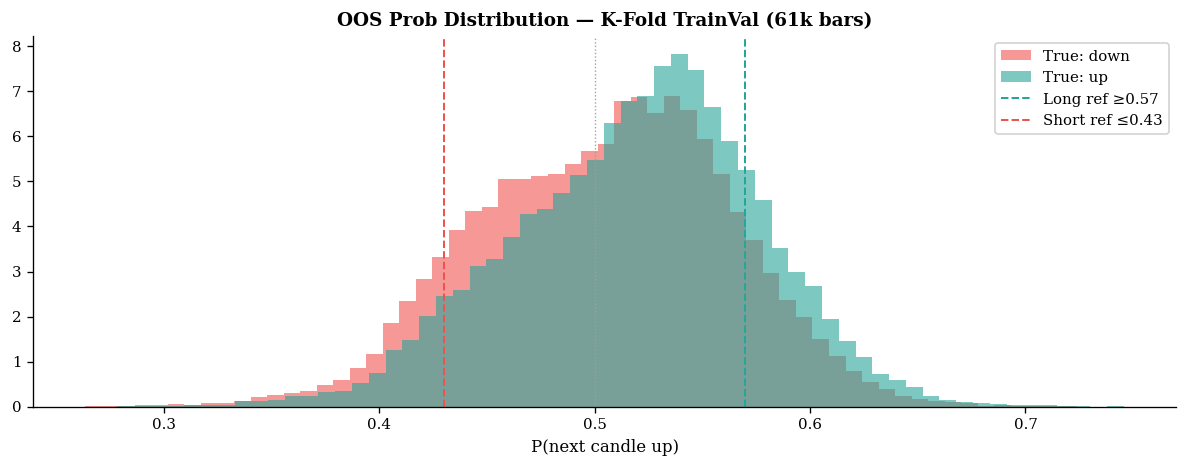

In [5]:
valid_mask = np.isfinite(oos_probs_tv)
oos_index  = trainval_df.index[valid_mask]
oos_probs  = oos_probs_tv[valid_mask]
oos_close  = trainval_df['close'].values[valid_mask]
oos_atr    = trainval_df['atr_14_pct'].values[valid_mask]
oos_labels = trainval_df['label'].values[valid_mask]

print(f'OOS probs  — mean={oos_probs.mean():.4f}  std={oos_probs.std():.4f}'
      f'  range=[{oos_probs.min():.4f}, {oos_probs.max():.4f}]')
print(f'OOS AUC    — {roc_auc_score(oos_labels, oos_probs):.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(oos_probs[oos_labels == 0], bins=60, alpha=0.6, color=RED,
        label='True: down', density=True)
ax.hist(oos_probs[oos_labels == 1], bins=60, alpha=0.6, color=GREEN,
        label='True: up',   density=True)
ax.axvline(0.57, color=GREEN, ls='--', lw=1.2, label='Long ref ≥0.57')
ax.axvline(0.43, color=RED,   ls='--', lw=1.2, label='Short ref ≤0.43')
ax.axvline(0.5,  color=GREY,  ls=':',  lw=0.8)
ax.set_xlabel('P(next candle up)')
ax.set_title('OOS Prob Distribution — K-Fold TrainVal (61k bars)', fontweight='bold')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'oos_prob_distribution_vtrain3.png')
plt.show()

## Phase 1 — Grid search on OOS probabilities

**Key change vs vtrain2:** both SL and TP are now ATR-relative.
At entry the backtest computes:
```
dynamic_sl = max(sl_atr_mult × ATR, min_sl)
dynamic_tp =     tp_atr_mult × ATR
```
Both targets scale with current volatility, so the grid search finds *ratios* rather
than absolute percentages that only worked in one volatility regime.

In [6]:
def run_backtest(probs, close_arr, atr_arr, sig_index, params):
    long_thr    = params['long_threshold']
    short_thr   = params['short_threshold']
    exit_long   = 1 - long_thr
    exit_short  = 1 - short_thr
    sl_atr_mult = params['sl_atr_multiplier']
    tp_atr_mult = params['tp_atr_multiplier']   # FIX 2: was static params['take_profit']
    min_sl      = params['min_sl']
    min_hold    = params['min_hold']
    max_hold    = params['max_hold']
    cooldown_n  = params['cooldown']

    cash = 1.0; units = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; entry_ts = None; entry_cash = 0.0
    dynamic_sl = 0.0; dynamic_tp = 0.0   # both set at entry, frozen until exit
    hold_count = 0; cooldown = 0

    equity_curve = [1.0]
    trade_log    = []

    for ts, px, conf, atr_pct in zip(sig_index, close_arr, probs, atr_arr):
        if cooldown > 0:
            cooldown -= 1

        if in_pos:
            hold_count += 1
            pnl = (px - entry_px) / entry_px if direction == 'long' \
                  else (entry_px - px) / entry_px
            reason = None
            if   pnl <= -dynamic_sl:         reason = 'sl'
            elif pnl >= dynamic_tp:          reason = 'tp'   # FIX 2: dynamic_tp
            elif hold_count >= max_hold:     reason = 'max_hold'
            elif hold_count >= min_hold:
                if direction == 'long'  and conf < exit_long:    reason = 'conf'
                elif direction == 'short' and conf > exit_short: reason = 'conf'

            if reason:
                cash  = units * px if direction == 'long' else entry_cash * (1 + pnl)
                units = 0.0
                trade_log.append({'direction': direction, 'pnl_pct': pnl,
                                   'hold_h': hold_count, 'reason': reason})
                in_pos = False; direction = None
                hold_count = 0;  cooldown = cooldown_n

        if not in_pos and cooldown == 0:
            # Both SL and TP are anchored to ATR at the moment of entry
            dynamic_sl = max(sl_atr_mult * atr_pct, min_sl)
            dynamic_tp = tp_atr_mult * atr_pct

            if conf >= long_thr:
                units = cash / px; cash = 0.0
                in_pos = True; direction = 'long'
                entry_px = px; entry_ts = ts; hold_count = 0
            elif conf <= short_thr:
                entry_cash = cash; units = cash / px
                in_pos = True; direction = 'short'
                entry_px = px; entry_ts = ts; hold_count = 0

        if in_pos and direction == 'long':
            equity_curve.append(units * px)
        elif in_pos and direction == 'short':
            equity_curve.append(entry_cash * (1 + (entry_px - px) / entry_px))
        else:
            equity_curve.append(cash)

    if in_pos:
        px  = close_arr[-1]
        pnl = (px - entry_px) / entry_px if direction == 'long' \
              else (entry_px - px) / entry_px
        cash = units * px if direction == 'long' else entry_cash * (1 + pnl)
        trade_log.append({'direction': direction, 'pnl_pct': pnl,
                           'hold_h': hold_count, 'reason': 'eod'})
        equity_curve[-1] = cash

    return np.array(equity_curve[1:]), pd.DataFrame(trade_log)


def score_equity(equity_arr, trades_df, metric):
    if trades_df.empty:
        return -np.inf
    eq  = equity_arr
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    ann = 24 * 365
    if metric == 'sharpe':
        return float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(ann))
    if metric == 'total_return':
        return float(eq[-1] - 1)
    if metric == 'calmar':
        ar  = float((eq[-1] ** (ann / len(eq))) - 1)
        pk  = np.maximum.accumulate(eq)
        mdd = float(((eq - pk) / (pk + 1e-12)).min())
        return ar / (abs(mdd) + 1e-6)
    if metric == 'win_rate':
        return float((trades_df['pnl_pct'] > 0).mean())
    if metric == 'profit_factor':
        g = trades_df[trades_df['pnl_pct'] > 0]['pnl_pct'].sum()
        l = trades_df[trades_df['pnl_pct'] < 0]['pnl_pct'].abs().sum()
        return float(g / (l + 1e-6))
    return -np.inf


print('run_backtest() and score_equity() defined  (TP is now ATR-relative).')

run_backtest() and score_equity() defined  (TP is now ATR-relative).


In [7]:
keys   = list(GRID.keys())
combos = list(itertools.product(*[GRID[k] for k in keys]))

valid_combos = [
    dict(zip(keys, v)) for v in combos
    if v[0] > 0.5           # long_threshold > 0.5
    and v[1] < 0.5           # short_threshold < 0.5
    and v[0] - (1 - v[1]) >= 0.02
]
print(f'Total combos : {len(combos):,}')
print(f'Valid combos : {len(valid_combos):,}')
print(f'Optimising   : {OPTIMISE_METRIC}')

results = []
for params in tqdm(valid_combos, desc='Grid search (OOS)'):
    eq, tdf = run_backtest(oos_probs, oos_close, oos_atr, oos_index, params)
    if len(tdf) < MIN_TRADES:
        continue

    s   = score_equity(eq, tdf, OPTIMISE_METRIC)
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)

    results.append({
        **params,
        'score':        s,
        'total_return': float(eq[-1] - 1),
        'sharpe':       float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365)),
        'max_dd':       float(((eq - pk) / (pk + 1e-12)).min()),
        'n_trades':     len(tdf),
        'win_rate':     float((tdf['pnl_pct'] > 0).mean()),
        'n_long':       int((tdf['direction'] == 'long').sum()),
        'n_short':      int((tdf['direction'] == 'short').sum()),
        'n_sl':         int((tdf['reason'] == 'sl').sum()),
        'n_tp':         int((tdf['reason'] == 'tp').sum()),
        'n_conf':       int((tdf['reason'] == 'conf').sum()),
    })

results_df = pd.DataFrame(results).sort_values('score', ascending=False).reset_index(drop=True)
print(f'\nValid results : {len(results_df):,}')
if not results_df.empty:
    print(f'Best {OPTIMISE_METRIC}   : {results_df["score"].iloc[0]:.4f}')
    print(f'Worst {OPTIMISE_METRIC}  : {results_df["score"].iloc[-1]:.4f}')

Total combos : 8,100
Valid combos : 1,944
Optimising   : sharpe


Grid search (OOS): 100%|██████████| 1944/1944 [00:58<00:00, 33.32it/s]


Valid results : 1,944
Best sharpe   : 1.7640
Worst sharpe  : 0.1134


In [8]:
display_cols = [
    'score', 'total_return', 'sharpe', 'max_dd', 'win_rate',
    'n_trades', 'n_long', 'n_short', 'n_sl', 'n_tp',
    'long_threshold', 'short_threshold',
    'sl_atr_multiplier', 'tp_atr_multiplier', 'min_sl',
    'min_hold', 'max_hold', 'cooldown',
]
top = results_df[display_cols].head(TOP_N).copy()
top['total_return'] = top['total_return'].map('{:+.2%}'.format)
top['max_dd']       = top['max_dd'].map('{:.2%}'.format)
top['win_rate']     = top['win_rate'].map('{:.1%}'.format)
top['score']        = top['score'].map('{:.4f}'.format)
top['sharpe']       = top['sharpe'].map('{:.3f}'.format)

best        = results_df.iloc[0]
best_params = {k: best[k] for k in keys}

print(f'Top {TOP_N} by {OPTIMISE_METRIC}  (OOS K-Fold, ATR-relative TP):\n')
print(top.to_string(index=True))
print(f'\n── Best config ──────────────────────────────────────────')
for k, v in best_params.items():
    print(f'  {k:<24}: {v}')
print(f'  {"OOS Sharpe":<24}: {best["sharpe"]:.4f}')
print(f'  {"OOS Return":<24}: {best["total_return"]:+.2%}')
print(f'  {"OOS MaxDD":<24}: {best["max_dd"]:.2%}')

Top 20 by sharpe  (OOS K-Fold, ATR-relative TP):

     score total_return sharpe   max_dd win_rate  n_trades  n_long  n_short  n_sl  n_tp  long_threshold  short_threshold  sl_atr_multiplier  tp_atr_multiplier  min_sl  min_hold  max_hold  cooldown
0   1.7640  +132111.79%  1.764  -50.26%    66.0%      4641    2030     2611   785  1127            0.57             0.46                2.5                1.5   0.010         4        48         3
1   1.7451  +127439.14%  1.745  -50.26%    66.5%      4517    1981     2536   608  1101            0.57             0.46                2.5                1.5   0.020         4        48         3
2   1.7098  +107107.53%  1.710  -50.26%    66.0%      4592    2007     2585   721  1115            0.57             0.46                2.5                1.5   0.015         4        48         3
3   1.6571   +52991.99%  1.657  -40.21%    62.7%      4473    1599     2874  1223  1223            0.59             0.45                1.5                1.5   0

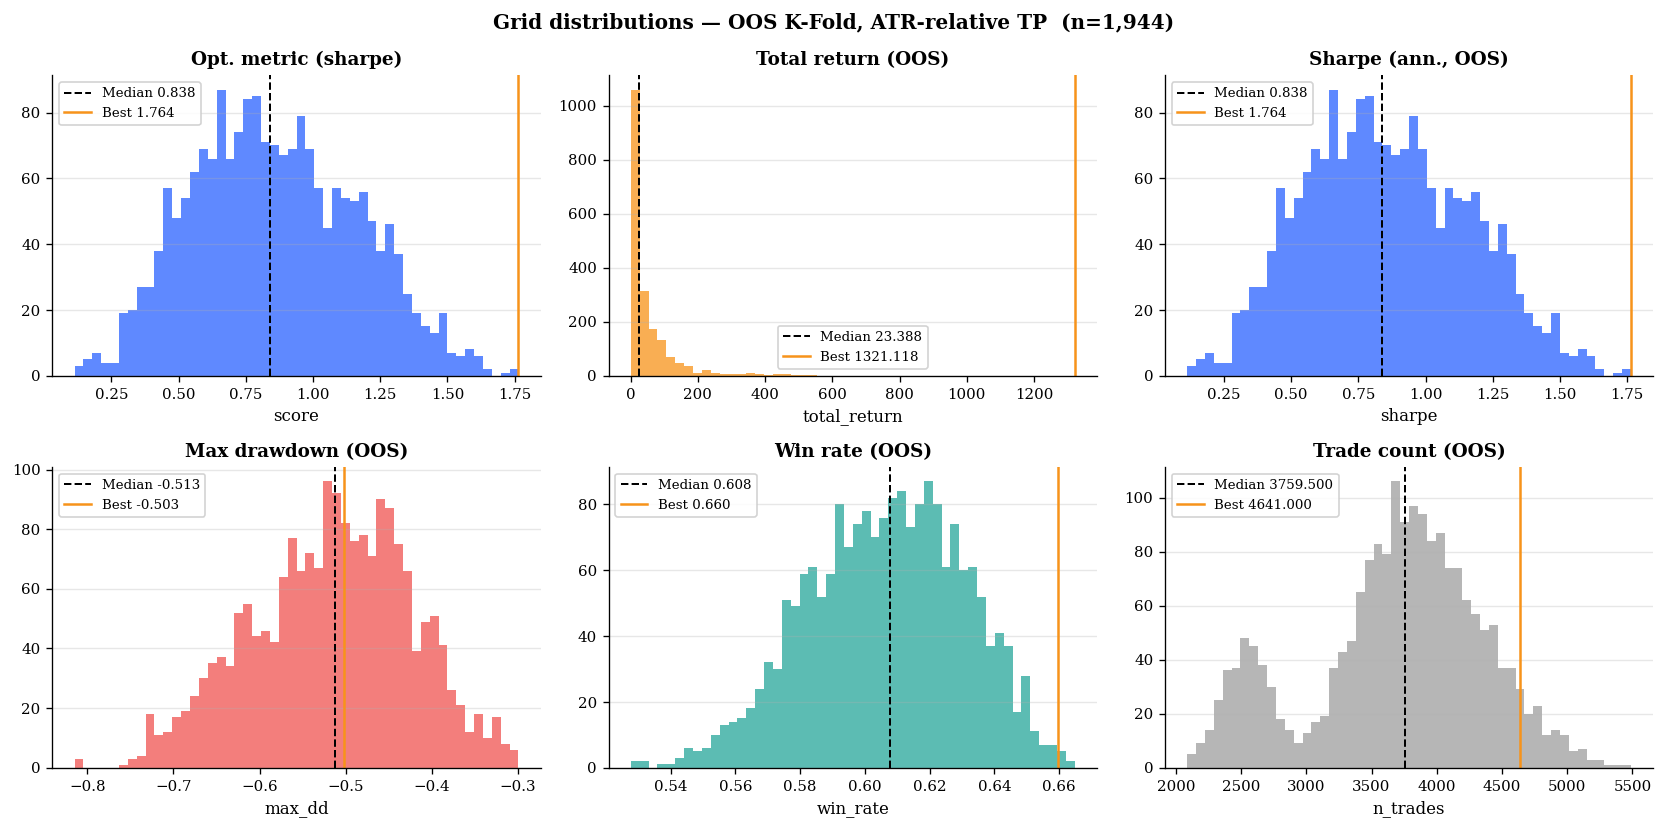

In [9]:
plot_cols = [
    ('score',        f'Opt. metric ({OPTIMISE_METRIC})', BLUE),
    ('total_return', 'Total return (OOS)',               ACCENT),
    ('sharpe',       'Sharpe (ann., OOS)',               BLUE),
    ('max_dd',       'Max drawdown (OOS)',               RED),
    ('win_rate',     'Win rate (OOS)',                   GREEN),
    ('n_trades',     'Trade count (OOS)',                GREY),
]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (col, title, color) in zip(axes.flat, plot_cols):
    data = results_df[col]
    ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(data.median(), color='black', lw=1.2, ls='--',
               label=f'Median {data.median():.3f}')
    ax.axvline(results_df[col].iloc[0], color=ACCENT, lw=1.5, ls='-',
               label=f'Best {results_df[col].iloc[0]:.3f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
fig.suptitle(f'Grid distributions — OOS K-Fold, ATR-relative TP  (n={len(results_df):,})',
             fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_search_distributions_vtrain3.png')
plt.show()

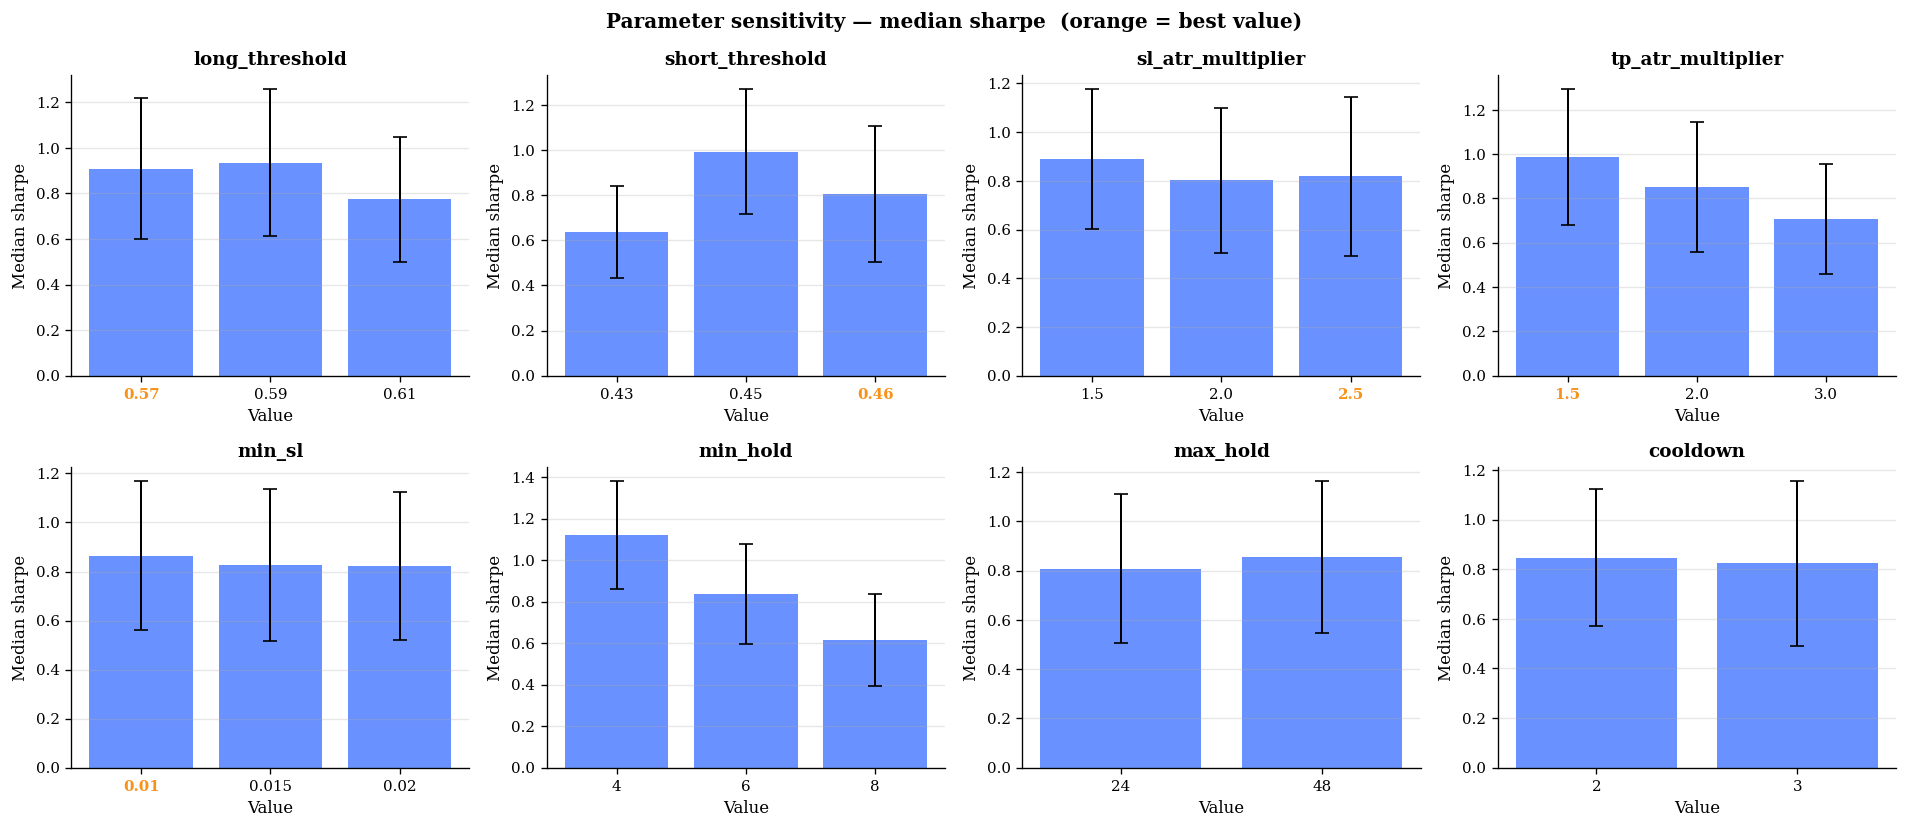

In [10]:
n_params = len(keys)
ncols = 4; nrows = int(np.ceil(n_params / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
for ax, param in zip(axes.flat, keys):
    grp = results_df.groupby(param)['score'].agg(['median', 'std']).reset_index()
    x   = grp[param].astype(str)
    ax.bar(x, grp['median'], color=BLUE, alpha=0.7)
    ax.errorbar(x, grp['median'], yerr=grp['std'],
                fmt='none', color='black', capsize=4, lw=1.2)
    ax.set_title(param, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel(f'Median {OPTIMISE_METRIC}')
    ax.grid(axis='y', alpha=0.3)
    best_val = str(best[param])
    for tick in ax.get_xticklabels():
        if tick.get_text() == best_val:
            tick.set_color(ACCENT); tick.set_fontweight('bold')
for ax in axes.flat[n_params:]:
    ax.set_visible(False)
fig.suptitle(f'Parameter sensitivity — median {OPTIMISE_METRIC}  (orange = best value)',
             fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_search_sensitivity_vtrain3.png')
plt.show()

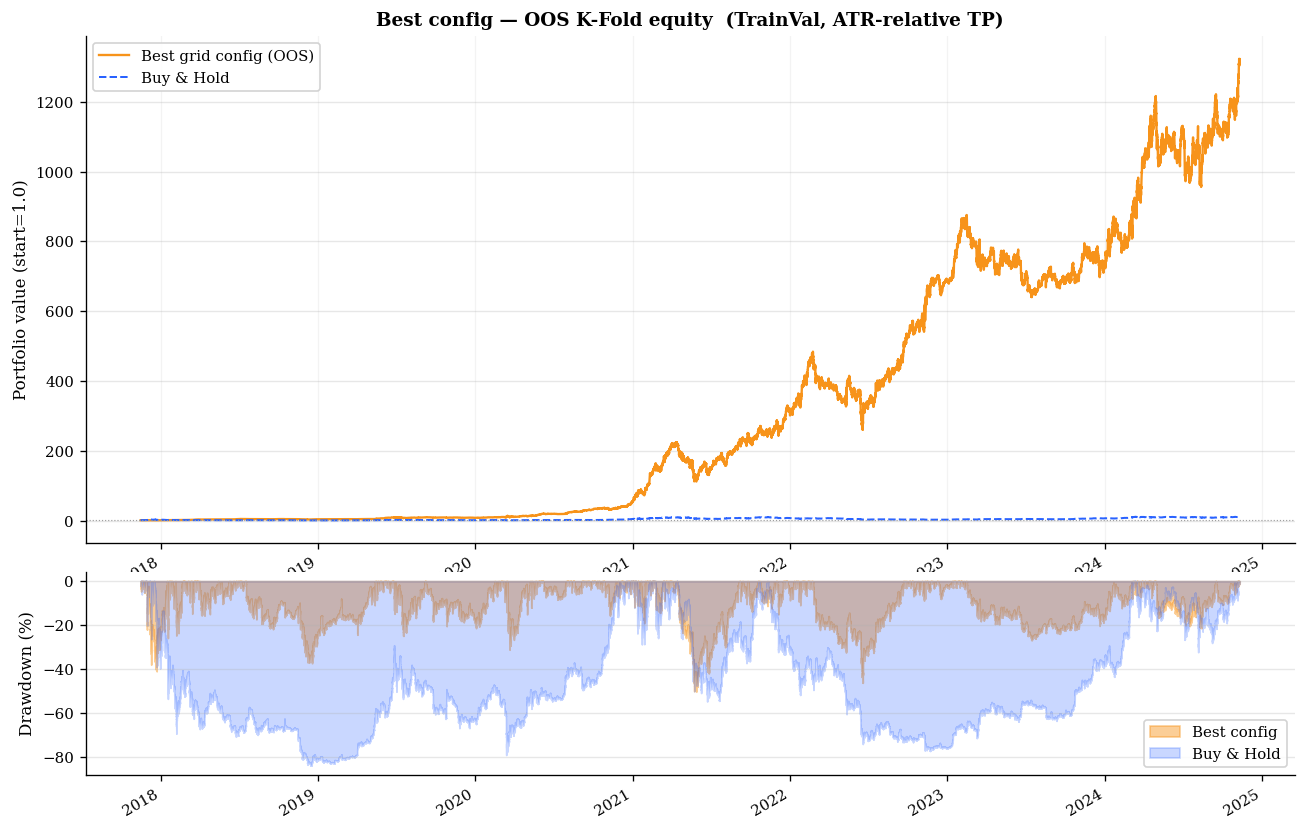

OOS K-Fold  |  Sharpe=1.764  Return=+132111.79%  MaxDD=-50.26%  Trades=4641


In [11]:
eq_oos, tdf_oos = run_backtest(oos_probs, oos_close, oos_atr, oos_index, best_params)
bh_oos_curve    = oos_close / oos_close[0]

fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})
ax = axes[0]
ax.plot(oos_index, eq_oos,       color=ACCENT, lw=1.4, label='Best grid config (OOS)')
ax.plot(oos_index, bh_oos_curve, color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value (start=1.0)')
ax.set_title('Best config — OOS K-Fold equity  (TrainVal, ATR-relative TP)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax = axes[1]
pk_s = np.maximum.accumulate(eq_oos)
pk_b = np.maximum.accumulate(bh_oos_curve)
ax.fill_between(oos_index, (eq_oos - pk_s) / (pk_s + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.45, label='Best config')
ax.fill_between(oos_index, (bh_oos_curve - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=BLUE, alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'grid_oos_best_equity_vtrain3.png')
plt.show()

ret_oos = np.log(np.maximum(eq_oos[1:], 1e-12) / np.maximum(eq_oos[:-1], 1e-12))
pk_oos  = np.maximum.accumulate(eq_oos)
print(f'OOS K-Fold  |  '
      f'Sharpe={ret_oos.mean()/(ret_oos.std(ddof=1)+1e-12)*np.sqrt(24*365):.3f}  '
      f'Return={eq_oos[-1]-1:+.2%}  '
      f'MaxDD={((eq_oos-pk_oos)/(pk_oos+1e-12)).min():.2%}  '
      f'Trades={len(tdf_oos)}')

## Phase 2 — Walk-Forward Optimization on test set (monthly retrain)

**Changes vs vtrain2:**
- `WFO_STEP_H = 720` — retrain monthly instead of weekly. Larger data chunks produce more stable tree splits.
- `WFO_INTERNAL_VAL_H = 2500` — same stable-val fix as Phase 1. Prevents premature 4-tree early stopping.
- ~18 retraining steps instead of 79.

Trading parameters (thresholds, SL/TP multipliers, hold times) come **only from Phase 1**
and are never touched here.

In [12]:
all_df = pd.concat([trainval_df, test_df]).sort_index()
n_tv   = len(trainval_df)
n_test = len(test_df)
X_all  = all_df[selected_features].values
y_all  = all_df['label'].values

wfo_probs   = np.full(n_test, np.nan)
wfo_n_trees = []
step = 0

t0_wfo = time.perf_counter()
t = 0
while t < n_test:
    step_end    = min(t + WFO_STEP_H, n_test)
    n_wfo_train = n_tv + t

    X_wfo = X_all[:n_wfo_train]
    y_wfo = y_all[:n_wfo_train]

    # Internal val: last WFO_INTERNAL_VAL_H bars of the growing training window
    n_int  = min(WFO_INTERNAL_VAL_H, int(0.10 * n_wfo_train))
    X_vl_w = X_wfo[-n_int:];  y_vl_w = y_wfo[-n_int:]
    X_tr_w = X_wfo[:-n_int];  y_tr_w = y_wfo[:-n_int]

    ds_tr_w = lgb.Dataset(X_tr_w, label=y_tr_w, feature_name=selected_features)
    ds_vl_w = lgb.Dataset(X_vl_w, label=y_vl_w,
                           feature_name=selected_features, reference=ds_tr_w)

    wfo_model = lgb.train(
        LGB_PARAMS, ds_tr_w,
        valid_sets=[ds_tr_w, ds_vl_w],
        valid_names=['train', 'val'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=WFO_PATIENCE, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    X_step = X_all[n_tv + t : n_tv + step_end]
    wfo_probs[t:step_end] = wfo_model.predict(X_step)
    wfo_n_trees.append(wfo_model.best_iteration)

    step += 1
    pct = step_end / n_test * 100
    print(f'Step {step:>2}  train={n_wfo_train:,}  int_val={n_int:,}  '
          f'best_iter={wfo_model.best_iteration:>4}  '
          f'prob=[{wfo_probs[t:step_end].min():.3f}, {wfo_probs[t:step_end].max():.3f}]  '
          f'{pct:.0f}%')

    del wfo_model
    t = step_end

elapsed = time.perf_counter() - t0_wfo
print(f'\nWFO done — {step} steps in {elapsed:.1f}s ({elapsed/step:.1f}s/step)')
print(f'best_iteration — mean={np.mean(wfo_n_trees):.0f}  '
      f'range=[{min(wfo_n_trees)}, {max(wfo_n_trees)}]')

Step  1  train=61,118  int_val=2,500  best_iter= 143  prob=[0.366, 0.675]  5%
Step  2  train=61,838  int_val=2,500  best_iter= 112  prob=[0.382, 0.674]  11%
Step  3  train=62,558  int_val=2,500  best_iter= 268  prob=[0.293, 0.700]  16%
Step  4  train=63,278  int_val=2,500  best_iter= 109  prob=[0.380, 0.665]  22%
Step  5  train=63,998  int_val=2,500  best_iter=  94  prob=[0.403, 0.646]  27%
Step  6  train=64,718  int_val=2,500  best_iter=  74  prob=[0.417, 0.634]  33%
Step  7  train=65,438  int_val=2,500  best_iter=  66  prob=[0.417, 0.627]  38%
Step  8  train=66,158  int_val=2,500  best_iter=  67  prob=[0.410, 0.628]  43%
Step  9  train=66,878  int_val=2,500  best_iter= 111  prob=[0.389, 0.651]  49%
Step 10  train=67,598  int_val=2,500  best_iter= 165  prob=[0.367, 0.643]  54%
Step 11  train=68,318  int_val=2,500  best_iter= 199  prob=[0.352, 0.671]  60%
Step 12  train=69,038  int_val=2,500  best_iter= 203  prob=[0.357, 0.666]  65%
Step 13  train=69,758  int_val=2,500  best_iter= 112 

WFO probs — mean=0.5054  std=0.0508  range=[0.2930, 0.7000]
WFO AUC   — 0.5479

Prob std comparison:
  K-Fold OOS (TrainVal) : 0.0582
  WFO test              : 0.0508
  Shrinkage             : 12.8%


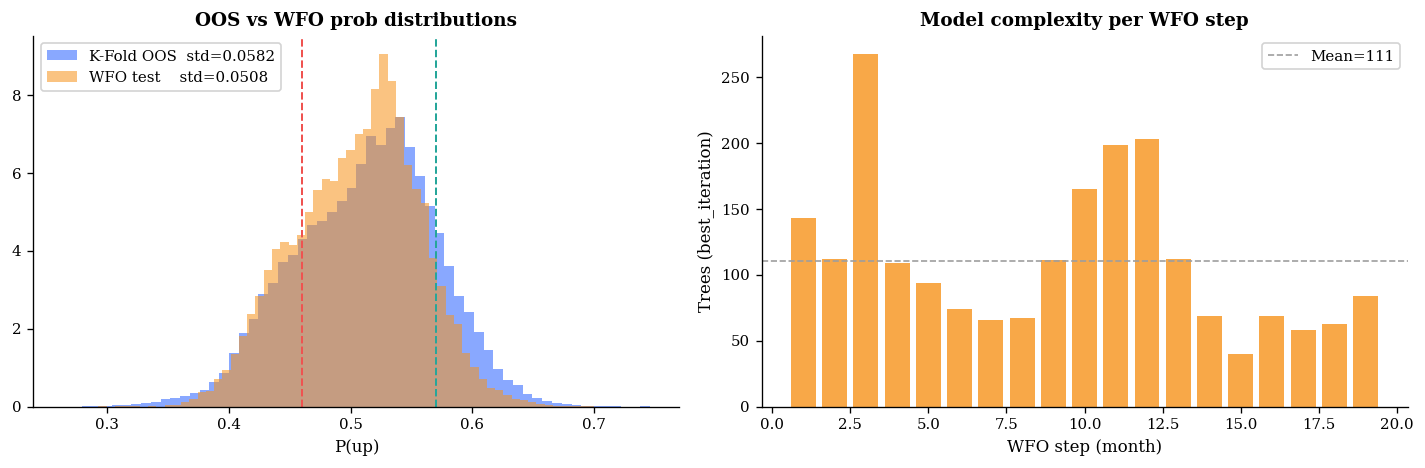

In [13]:
print(f'WFO probs — mean={wfo_probs.mean():.4f}  std={wfo_probs.std():.4f}'
      f'  range=[{wfo_probs.min():.4f}, {wfo_probs.max():.4f}]')
print(f'WFO AUC   — {roc_auc_score(y_test, wfo_probs):.4f}')

# Compare prob distributions: K-Fold OOS vs WFO test
print(f'\nProb std comparison:')
print(f'  K-Fold OOS (TrainVal) : {oos_probs.std():.4f}')
print(f'  WFO test              : {wfo_probs.std():.4f}')
print(f'  Shrinkage             : {(1 - wfo_probs.std()/oos_probs.std())*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(oos_probs,  bins=60, alpha=0.55, color=BLUE,  label=f'K-Fold OOS  std={oos_probs.std():.4f}', density=True)
ax.hist(wfo_probs,  bins=60, alpha=0.55, color=ACCENT, label=f'WFO test    std={wfo_probs.std():.4f}', density=True)
ax.axvline(best_params['long_threshold'],  color=GREEN, ls='--', lw=1.2)
ax.axvline(best_params['short_threshold'], color=RED,   ls='--', lw=1.2)
ax.set_xlabel('P(up)'); ax.set_title('OOS vs WFO prob distributions', fontweight='bold')
ax.legend()

ax = axes[1]
weeks = np.arange(1, len(wfo_n_trees) + 1)
ax.bar(weeks, wfo_n_trees, color=ACCENT, alpha=0.8)
ax.axhline(np.mean(wfo_n_trees), color=GREY, ls='--', lw=1,
           label=f'Mean={np.mean(wfo_n_trees):.0f}')
ax.set_xlabel('WFO step (month)'); ax.set_ylabel('Trees (best_iteration)')
ax.set_title('Model complexity per WFO step', fontweight='bold')
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'wfo_prob_stats_vtrain3.png')
plt.show()

In [14]:
sig_index_test = test_df.index
close_test     = test_df['close'].values
atr_test       = test_df['atr_14_pct'].values
bh_test        = close_test / close_test[0]

eq_wfo, tdf_wfo = run_backtest(
    wfo_probs, close_test, atr_test, sig_index_test, best_params
)

# Static production model for comparison (uses same ATR-relative params)
prod_model   = lgb.Booster(model_file=str(MODELS_DIR / 'lgbm_model.txt'))
probs_static = prod_model.predict(X_test)
eq_static, tdf_static = run_backtest(
    probs_static, close_test, atr_test, sig_index_test, best_params
)

def quick_metrics(eq, tdf, label):
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)
    sh  = float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))
    mdd = float(((eq - pk) / (pk + 1e-12)).min())
    wr  = float((tdf['pnl_pct'] > 0).mean()) if not tdf.empty else float('nan')
    print(f'  {label:<32}  Return={eq[-1]-1:+.2%}  Sharpe={sh:.3f}  '
          f'MaxDD={mdd:.2%}  Trades={len(tdf)}  WinRate={wr:.1%}')

print('── Test results (trading params from OOS K-Fold, ATR-relative TP) ──────────')
quick_metrics(eq_wfo,    tdf_wfo,    'WFO monthly retrain (vtrain3)')
quick_metrics(eq_static, tdf_static, 'Static model (nb 06)')
quick_metrics(bh_test,   pd.DataFrame(), 'Buy & Hold')

── Test results (trading params from OOS K-Fold, ATR-relative TP) ──────────
  WFO monthly retrain (vtrain3)     Return=+106.13%  Sharpe=1.397  MaxDD=-21.60%  Trades=897  WinRate=65.2%
  Static model (nb 06)              Return=+54.35%  Sharpe=0.839  MaxDD=-25.46%  Trades=971  WinRate=64.4%
  Buy & Hold                        Return=+3.14%  Sharpe=0.044  MaxDD=-50.08%  Trades=0  WinRate=nan%


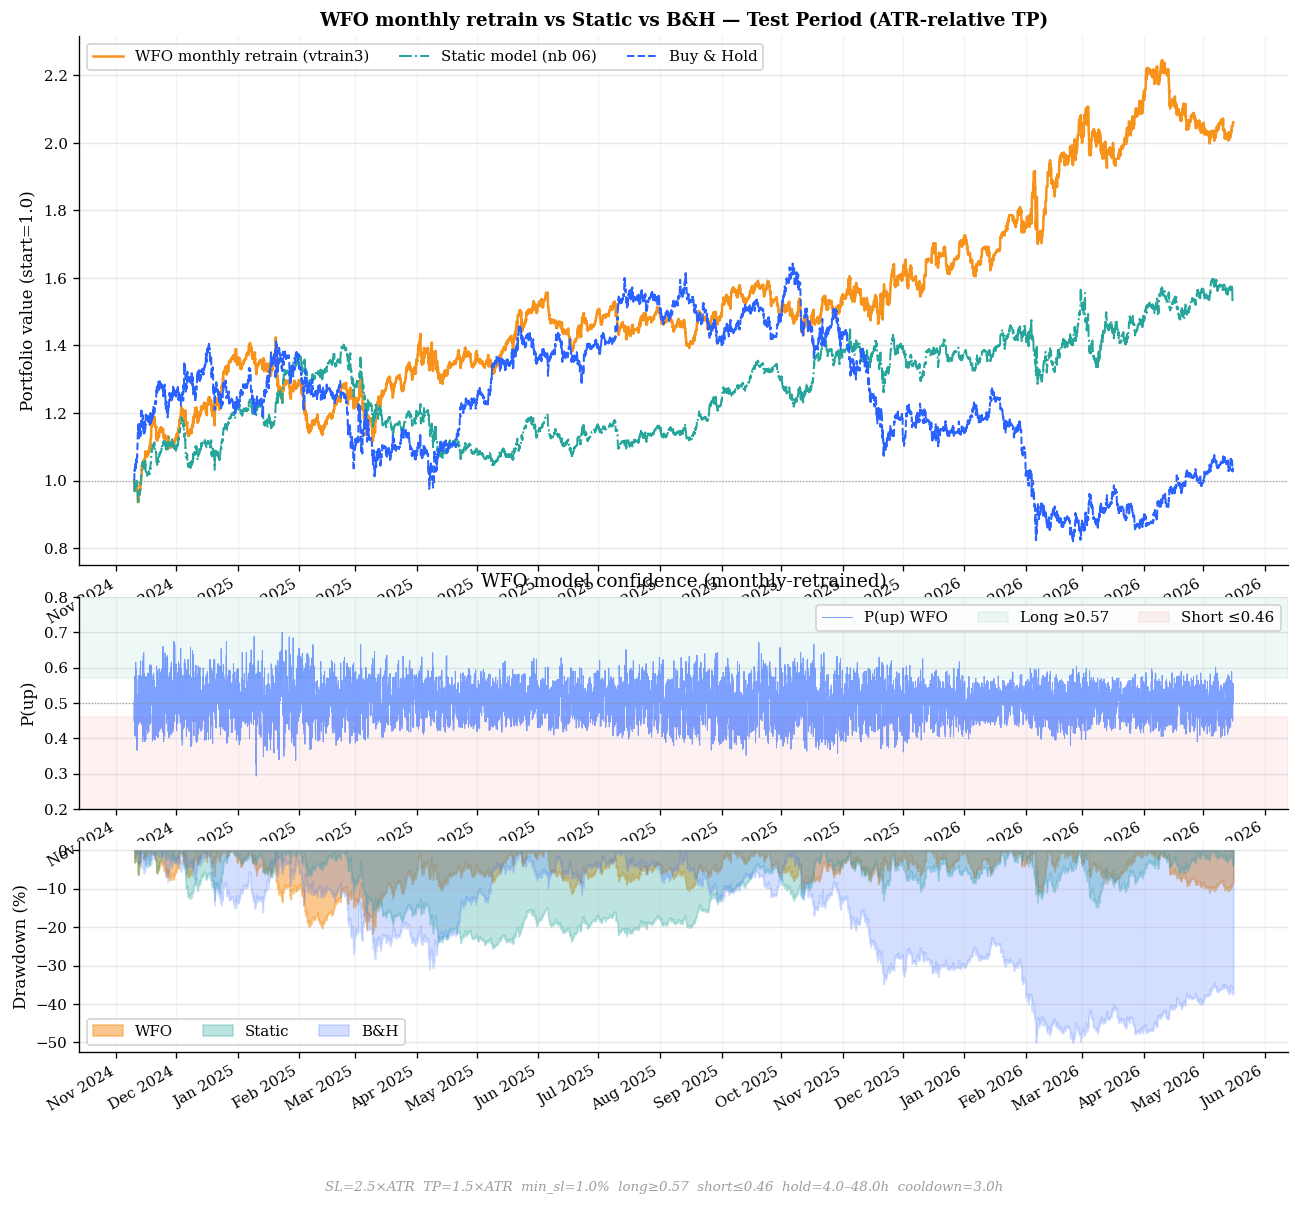

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11),
                          gridspec_kw={'height_ratios': [3, 1.2, 1.2], 'hspace': 0.10})

ax = axes[0]
ax.plot(sig_index_test, eq_wfo,    color=ACCENT, lw=1.5, label='WFO monthly retrain (vtrain3)')
ax.plot(sig_index_test, eq_static, color=GREEN,  lw=1.2, ls='-.', label='Static model (nb 06)')
ax.plot(sig_index_test, bh_test,   color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value (start=1.0)')
ax.set_title('WFO monthly retrain vs Static vs B&H — Test Period (ATR-relative TP)',
             fontweight='bold')
ax.legend(ncol=3); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax = axes[1]
ax.plot(sig_index_test, wfo_probs, color=BLUE, lw=0.6, alpha=0.6, label='P(up) WFO')
ax.axhspan(best_params['long_threshold'],  1.0, alpha=0.08, color=GREEN,
           label=f'Long ≥{best_params["long_threshold"]}')
ax.axhspan(0.0, best_params['short_threshold'], alpha=0.08, color=RED,
           label=f'Short ≤{best_params["short_threshold"]}')
ax.axhline(0.5, color=GREY, ls=':', lw=0.7)
ax.set_ylim(0.2, 0.8); ax.set_ylabel('P(up)')
ax.set_title('WFO model confidence (monthly-retrained)')
ax.legend(ncol=3); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax = axes[2]
pk_w = np.maximum.accumulate(eq_wfo)
pk_s = np.maximum.accumulate(eq_static)
pk_b = np.maximum.accumulate(bh_test)
ax.fill_between(sig_index_test, (eq_wfo    - pk_w) / (pk_w + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.50, label='WFO')
ax.fill_between(sig_index_test, (eq_static - pk_s) / (pk_s + 1e-12) * 100, 0,
                color=GREEN,  alpha=0.30, label='Static')
ax.fill_between(sig_index_test, (bh_test   - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=BLUE,   alpha=0.20, label='B&H')
ax.set_ylabel('Drawdown (%)'); ax.legend(ncol=3)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.005,
    f'SL={best_params["sl_atr_multiplier"]}×ATR  TP={best_params["tp_atr_multiplier"]}×ATR  '
    f'min_sl={best_params["min_sl"]*100:.1f}%  '
    f'long≥{best_params["long_threshold"]}  short≤{best_params["short_threshold"]}  '
    f'hold={best_params["min_hold"]}–{best_params["max_hold"]}h  '
    f'cooldown={best_params["cooldown"]}h',
    ha='center', fontsize=8, color=GREY, style='italic')

fig.savefig(FIGURES_DIR / 'grid_wfo_equity_vtrain3.png')
plt.show()

In [16]:
def full_metrics(eq, tdf, label):
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)
    sh  = float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))
    mdd = float(((eq - pk) / (pk + 1e-12)).min())
    an  = float((eq[-1] ** (24 * 365 / len(eq))) - 1)
    cal = an / (abs(mdd) + 1e-6)
    wr  = float((tdf['pnl_pct'] > 0).mean()) if not tdf.empty else float('nan')
    pf  = 0.0
    if not tdf.empty:
        g  = tdf[tdf['pnl_pct'] > 0]['pnl_pct'].sum()
        l  = tdf[tdf['pnl_pct'] < 0]['pnl_pct'].abs().sum()
        pf = g / (l + 1e-6)
    return {
        'Strategy':      label,
        'Total Return':  f'{eq[-1]-1:+.2%}',
        'Ann. Return':   f'{an:+.2%}',
        'Sharpe (ann.)': f'{sh:.3f}',
        'Max Drawdown':  f'{mdd:.2%}',
        'Calmar':        f'{cal:.3f}',
        'Win Rate':      f'{wr:.1%}' if not np.isnan(wr) else 'N/A',
        'Profit Factor': f'{pf:.3f}' if pf else 'N/A',
        'Trades':        str(len(tdf)),
    }

summary = pd.DataFrame([
    full_metrics(eq_wfo,    tdf_wfo,    'WFO monthly retrain (vtrain3)'),
    full_metrics(eq_static, tdf_static, 'Static model (nb 06 / vtrain)'),
    full_metrics(bh_test,   pd.DataFrame(), 'Buy & Hold'),
]).set_index('Strategy')

print('\n' + '=' * 72)
print('  FINAL TEST-SET SUMMARY — vtrain3')
print('=' * 72)
print(summary.to_string())
print('=' * 72)

# Sanity check: is OOS Sharpe sane now that TP is ATR-relative?
ret_oos = np.log(np.maximum(eq_oos[1:], 1e-12) / np.maximum(eq_oos[:-1], 1e-12))
pk_oos  = np.maximum.accumulate(eq_oos)
print(f'\n  OOS K-Fold (TrainVal, 61k bars)  [sanity check — should be plausible, not 17000%]')
print(f'  OOS Sharpe  = {ret_oos.mean()/(ret_oos.std(ddof=1)+1e-12)*np.sqrt(24*365):.4f}')
print(f'  OOS Return  = {eq_oos[-1]-1:+.2%}')
print(f'  OOS Trades  = {len(tdf_oos)}')


  FINAL TEST-SET SUMMARY — vtrain3
                              Total Return Ann. Return Sharpe (ann.) Max Drawdown Calmar Win Rate Profit Factor Trades
Strategy                                                                                                              
WFO monthly retrain (vtrain3)     +106.13%     +61.33%         1.397      -21.60%  2.839    65.2%         1.185    897
Static model (nb 06 / vtrain)      +54.35%     +33.24%         0.839      -25.46%  1.305    64.4%         1.114    971
Buy & Hold                          +3.14%      +2.07%         0.044      -50.08%  0.041      N/A           N/A      0

  OOS K-Fold (TrainVal, 61k bars)  [sanity check — should be plausible, not 17000%]
  OOS Sharpe  = 1.7640
  OOS Return  = +132111.79%
  OOS Trades  = 4641


In [17]:
results_path = MODELS_DIR / 'lgbm_grid_results_vtrain3.csv'
results_df.to_csv(results_path, index=False)
print(f'Saved {len(results_df):,} grid results → {results_path}')

ret_w = np.log(np.maximum(eq_wfo[1:], 1e-12) / np.maximum(eq_wfo[:-1], 1e-12))
pk_w  = np.maximum.accumulate(eq_wfo)
ret_oos2 = np.log(np.maximum(eq_oos[1:], 1e-12) / np.maximum(eq_oos[:-1], 1e-12))

output = {
    'version':          'vtrain3',
    'changes_vs_vtrain2': [
        'WFO_STEP_H 168->720 (monthly)',
        'WFO_INTERNAL_VAL_H 720->2500 (stable early-stop)',
        'take_profit (static %) -> tp_atr_multiplier (ATR-relative)',
    ],
    'selection_method': 'purged_kfold_option2_trainval',
    'wfo_retrain_freq': f'{WFO_STEP_H}h',
    'params':           best_params,
    'oos_kfold': {
        'sharpe':       round(float(ret_oos2.mean()/(ret_oos2.std(ddof=1)+1e-12)*np.sqrt(24*365)), 4),
        'total_return': round(float(eq_oos[-1] - 1), 4),
        'n_trades':     int(len(tdf_oos)),
    },
    'test_wfo': {
        'sharpe':       round(float(ret_w.mean()/(ret_w.std(ddof=1)+1e-12)*np.sqrt(24*365)), 4),
        'total_return': round(float(eq_wfo[-1] - 1), 4),
        'max_dd':       round(float(((eq_wfo-pk_w)/(pk_w+1e-12)).min()), 4),
        'n_trades':     int(len(tdf_wfo)),
    },
}

params_path = MODELS_DIR / 'lgbm_best_trading_params_vtrain3.json'
with open(params_path, 'w') as f:
    json.dump(output, f, indent=2)
print(f'Saved best params  → {params_path}')
print()
print(json.dumps(output, indent=2))

Saved 1,944 grid results → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/lgbm_grid_results_vtrain3.csv
Saved best params  → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/lgbm_best_trading_params_vtrain3.json

{
  "version": "vtrain3",
  "changes_vs_vtrain2": [
    "WFO_STEP_H 168->720 (monthly)",
    "WFO_INTERNAL_VAL_H 720->2500 (stable early-stop)",
    "take_profit (static %) -> tp_atr_multiplier (ATR-relative)"
  ],
  "selection_method": "purged_kfold_option2_trainval",
  "wfo_retrain_freq": "720h",
  "params": {
    "long_threshold": 0.57,
    "short_threshold": 0.46,
    "sl_atr_multiplier": 2.5,
    "tp_atr_multiplier": 1.5,
    "min_sl": 0.01,
    "min_hold": 4.0,
    "max_hold": 48.0,
    "cooldown": 3.0
  },
  "oos_kfold": {
    "sharpe": 1.764,
    "total_return": 1321.1179,
    "n_trades": 4641
  },
  "test_wfo": {
    "sharpe": 1.3969,
    "total_return": 1.0613,
    "max_dd": -0.216,
    "n_trades": 897
 